# Лабораторна робота №4 "Класифікація"
**Мета.** Ознайомитися з основами **класифікації** при інтелектуальному аналізі даних на прикладі реального історичного набору даних **Titanic**. Навчитись будувати **класифікатор на основі дерев рішень (Decision Tree)**, виконувати попередню обробку даних, навчати модель, оцінювати якість класифікації за допомогою стандартних метрик та інтерпретувати отримані результати. 

## 1. Завантаження та попередня обробка даних

In [1]:
import os
import requests
import pandas as pd
import numpy as np

Створимо папку `tmp/lab_4` (якщо не існує).

In [2]:
tmp_path = "tmp/lab_4"
os.makedirs(tmp_path, exist_ok=True)

Оскільки Kaggle потребує авторизації та API токенів, використаємо дзеркало з github для завантаження датасету.

In [3]:
dataset_url = "https://raw.githubusercontent.com/agconti/kaggle-titanic/refs/heads/master/data/train.csv"
dataset_filepath = os.path.join(tmp_path, "train.csv")

if not os.path.exists(dataset_filepath):
    response = requests.get(dataset_url)
    if response.status_code == 200:
        with open(dataset_filepath, "wb") as f:
            f.write(response.content)
        print("Файл успішно завантажено.\n")
    else:
        raise Exception(f"Не вдалося завантажити дані. Статус: {response.status_code}")

Створимо DataFrame.

In [4]:
df = pd.read_csv(dataset_filepath)

Виведемо загальну інформацію про дані та перевіримо наявність пропущених значень.

In [5]:
print("Загальна інформація про дані")
print(df.info())
print("\nКількість пропущених значень")
print(df.isnull().sum())

Загальна інформація про дані
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None

Кількість пропущених значень
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin

### Заповнення пропущених значень

Заповнимо вік медіаною, а порт посадки – найчастішим значенням (модою), оскільки ми не можемо взяти медіану чи середнє значення від категоріальних даних.

In [6]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

### Перетворення категоріальних ознак у числовий формат
Видалимо колонку Cabin через велику кількість пропусків. Колонки PassengerId, Name та Ticket нерелевантні для нашого дослідження, тому теж будуть видалені.

In [7]:
df.drop(columns=['Cabin', 'PassengerId', 'Name', 'Ticket'], inplace=True)

Оскільки категорія "стать" має лише два варіанти, використаємо бінарний формат: 0 -> Чоловік, 1 -> Жінка.

In [8]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

Оскільки варіантів портів посадки може бути більше за 2, ми не можемо використати цілі числа, бо дерево рішень сприйматиме це як ієрархію. Замість цього створимо колонки для кожного унікального порту, де 1 означає присутність ознаки, а 0 – відсутність.

`drop_first` означає, що ми видаляємо першу колонку (в даному випадку це Cherbourg) для уникнення надлишковості даних. В такому випадку якщо Embarked_Q та Embarked_S матимуть значення False, це означатиме, що портом посадки є Шербург.

In [9]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

Виведемо кілька рядків з оброблених даних:

In [10]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


## 2. Поділ даних на навчальну та тестову вибірки

In [11]:
from sklearn.model_selection import train_test_split

Виділимо цільову змінну (y) та ознаки (X).

In [12]:
X = df.drop('Survived', axis=1)
y = df['Survived']

Поділимо у пропорції 80/20 за допомогою `train_test_split` з пакету `sklearn`. Параметр `random_state` забезпечує збереження однакової вибірки при повторному виконанні.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)

print(f"Розмір навчальної вибірки (X_train): {X_train.shape}")
print(f"Розмір тестової вибірки (X_test): {X_test.shape}")
print(f"Розмір цільової змінної навчання (y_train): {y_train.shape}")
print(f"Розмір цільової змінної тесту (y_test): {y_test.shape}")

Розмір навчальної вибірки (X_train): (712, 8)
Розмір тестової вибірки (X_test): (179, 8)
Розмір цільової змінної навчання (y_train): (712,)
Розмір цільової змінної тесту (y_test): (179,)


## 3. Побудова класифікатора на основі дерев рішень

In [14]:
from sklearn.tree import DecisionTreeClassifier

### Навчання моделі дерева рішень на навчальних даних

In [15]:
clf = DecisionTreeClassifier(random_state=67)
clf.fit(X_train, y_train);

### Отримання класифікації для тестової вибірки

In [16]:
y_pred = clf.predict(X_test)

### Аналіз глибини дерева та кількості вузлів

In [17]:
tree_depth = clf.get_depth()
node_count = clf.tree_.node_count

print(f"Глибина побудованого дерева: {tree_depth}")
print(f"Загальна кількість вузлів у дереві: {node_count}")

Глибина побудованого дерева: 19
Загальна кількість вузлів у дереві: 315


## 4. Оцінювання якості класифікації

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

Обчислимо основні метрики класифікації.

In [19]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.7598
Precision: 0.7391
Recall:    0.6711
F1-score:  0.7034


Можна сказати, що модель має середню точність (краще за випадковий вибір, проте не >90% точності). Щоб детальніше оцінити її поведінку, створимо Confusion Matrix.

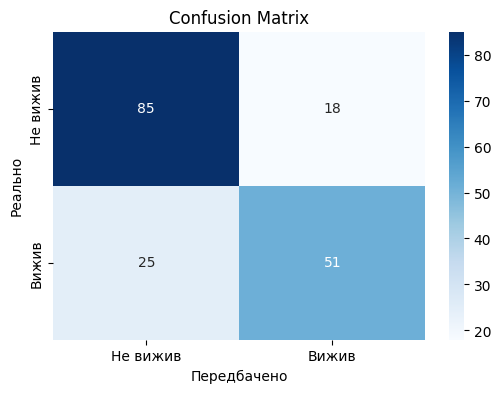

In [20]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Не вижив', 'Вижив'], 
            yticklabels=['Не вижив', 'Вижив'])
plt.title('Confusion Matrix')
plt.xlabel('Передбачено')
plt.ylabel('Реально')
plt.show()

Можна побачити, що модель досить "консервативна", і частіше передбачає, що людина не вижила. Виведемо детальний звіт класифікації для точнішої оцінки.

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.83      0.80       103
           1       0.74      0.67      0.70        76

    accuracy                           0.76       179
   macro avg       0.76      0.75      0.75       179
weighted avg       0.76      0.76      0.76       179



Отже головною слабкістю моделлі є слабкий recall для позитивних випадків (великий відсоток FN).

## Інтерпретація моделі

In [22]:
from sklearn.tree import plot_tree

### Feature importance
Цей показник демонструє, наскільки кожна характеристика (стать, вік, клас тощо) допомогла дереву зменшити «невизначеність» при класифікації пасажирів.

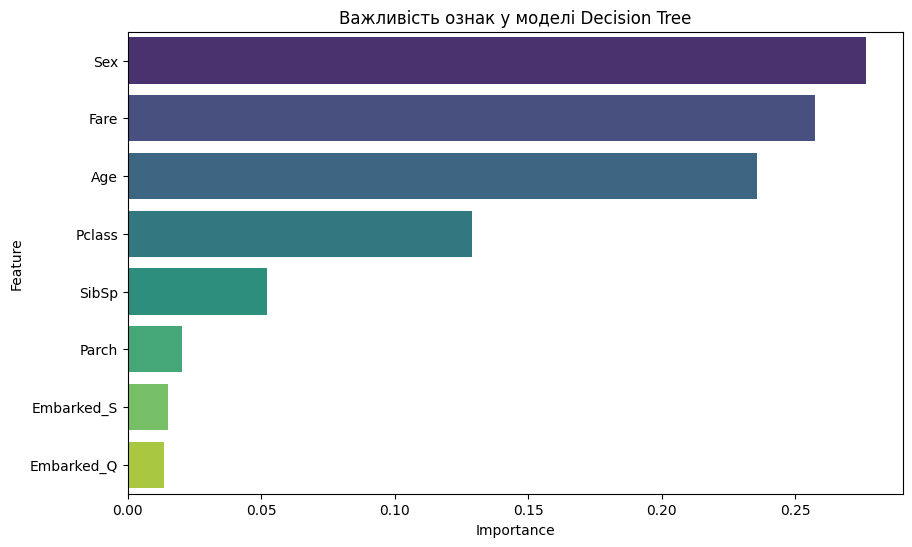

      Feature  Importance
1         Sex    0.276486
5        Fare    0.257313
2         Age    0.235851
0      Pclass    0.129069
3       SibSp    0.052358
4       Parch    0.020292
7  Embarked_S    0.014954
6  Embarked_Q    0.013676


In [23]:
importances = clf.feature_importances_
features = X.columns

feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis', hue='Feature')
plt.title('Важливість ознак у моделі Decision Tree')
plt.show()

print(feature_importance_df)

Досить очікувано, що найголовнішими характеристиками є стать (жінки рятувалися частіше), вартість квитка (багатші клієнти мали більший шанс на порятунок) та вік (дітей рятували разом з жінками). При цьому посадка в конкретному порту фактично нічого не означає (оскільки є непов'язаною з порятунком).

## Візуалізація дерева рішень

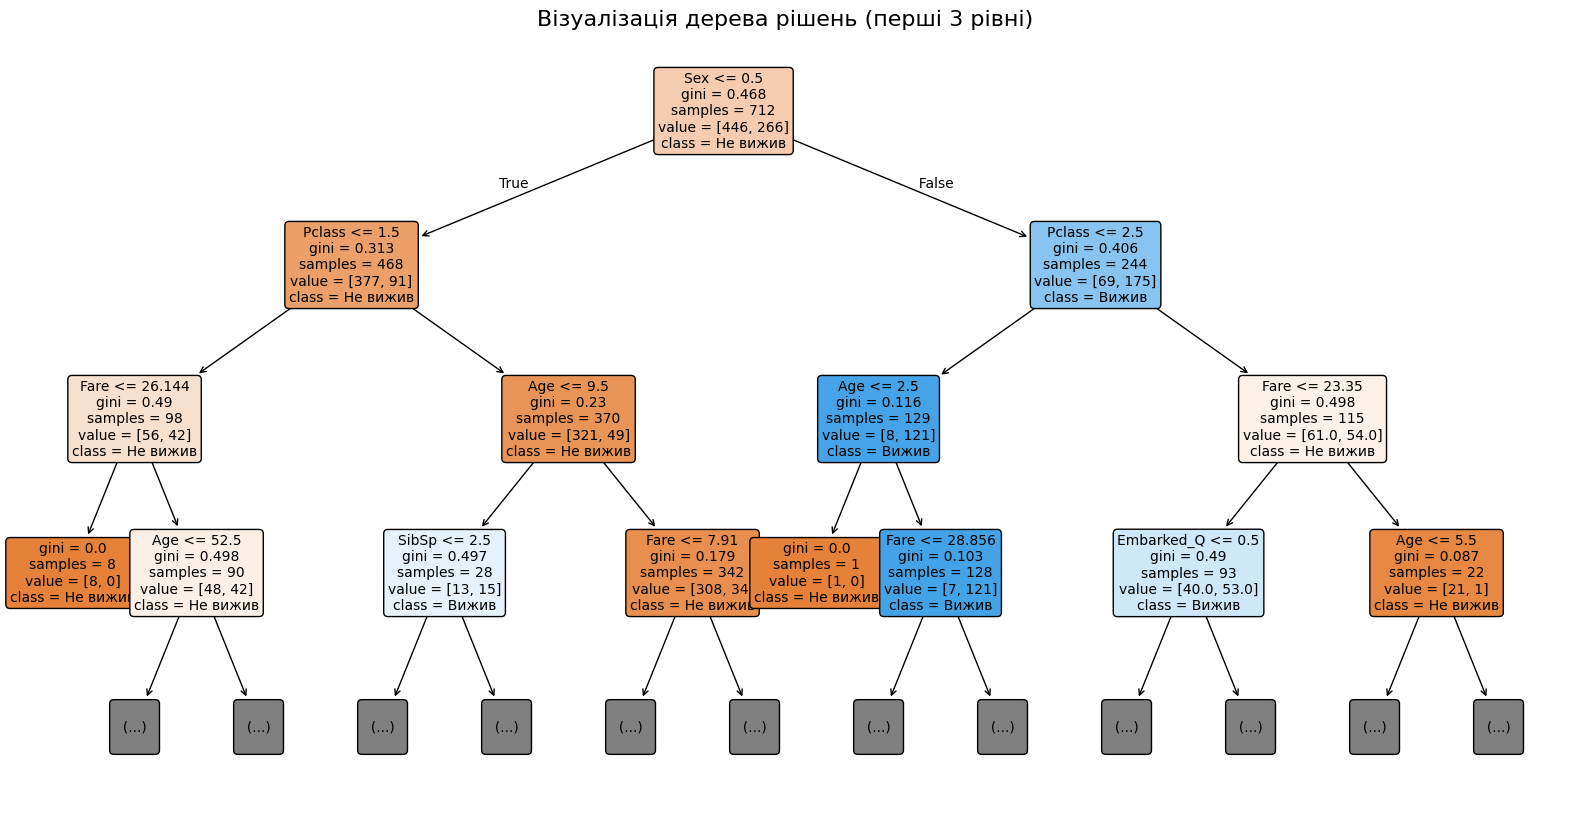

In [24]:
plt.figure(figsize=(20, 10))

plot_tree(clf, 
          feature_names=X.columns.tolist(),
          class_names=['Не вижив', 'Вижив'],
          filled=True,
          rounded=True,
          max_depth=3,
          fontsize=10)

plt.title('Візуалізація дерева рішень (перші 3 рівні)', fontsize=16)
plt.show()

За кольором можна оцінити, яка група пасажирів переважає: тих, що вижили, чи тих, що померли.

# Висновки
У ході роботи було опановано метод класифікації за допомогою дерев рішень на прикладі датасету Titanic, пройшовши всі етапи від підготовки даних до оцінки метрик. Модель продемонструвала загальну точність 76% та F1-score 0.70, що свідчить про її спроможність знаходити закономірності, хоча нижчий показник повноти (Recall) для класу тих, хто вижив, вказує на певну «обережність» алгоритму.

Аналіз важливості ознак та візуалізація дерева підтвердили, що ключовими факторами порятунку стали стать, клас каюти (і пов'язана з цим ціна квитка) та вік, що повністю відповідає історичним даним про катастрофу. Головною перевагою обраного методу виявилася його висока інтерпретованість, яка дозволила наочно простежити логіку прийняття рішень моделлю.

In [25]:
import shutil

if os.path.exists(tmp_path):
    shutil.rmtree(tmp_path)